# LAB- P6: La Empresa y la Decisión de Inversión (Modelo Q de Tobin)
**Proyecto MACRO-AI-COMP (Convocatoria INNOVA26, UMA / Banco Santander)**
*   **Código de LAB-**: LAB-P6-v1.0
*   **Capítulo de Referencia**: Capítulo 7, *An Introduction to Computational Macroeconomics* (Bongers, Gómez y Torres, Vernon Press, 2019)
*   **Autores**: Equipo Docente MACRO-AI-COMP
*   **Objetivo**: Modelar la decisión de inversión de una empresa competitiva que enfrenta costos de ajuste cuadráticos en la instalación del capital físico. Estudiaremos:
    1. La derivación analítica de la dinámica del capital ($K_t$) y la Q de Tobin marginal ($q_t$).
    2. La log-linealización del modelo y la resolución mediante autovalores del stable saddle path (Uhlig, 1999).
    3. La resolución numérica del modelo no lineal exacto utilizando `scipy.optimize.fsolve`.
    4. La simulación y análisis de shocks permanentes en la tasa de interés real, evaluando el "salto" instantáneo de la variable forward-looking ($q_t$) y la transición gradual del capital ($K_t$).
    5. La visualización de la dinámica del sistema en el diagrama de fases.

---

## Objetivos de Aprendizaje
Al finalizar esta práctica, serás capaz de:
1.  **Comprender** el concepto de la Q de Tobin marginal y su relación con el precio de sombra de los activos físicos.
2.  **Analizar** cómo los costos de ajuste de la inversión ralentizan el proceso de acumulación de capital físico, rompiendo la equivalencia directa instantánea entre ahorro e inversión.
3.  **Calcular** la estabilidad del sistema dinámico mediante el análisis de autovalores, identificando la naturaleza del punto de silla (saddle point).
4.  **Resolver** la condición de salto de las expectativas para determinar el comportamiento instantáneo de las variables flexibles (jump variables).
5.  **Comparar** de forma crítica la precisión de la aproximación linealizada frente al modelo no lineal exacto.
6.  **Graficar e interpretar** un diagrama de fases dinámico con curvas de demarcación y campos de vectores en el plano de fases.
 (Julia)

> **👋 BIENVENIDA A LA PRÁCTICA - LEER ANTES DE EMPEZAR**
> 
> *   **¿Nunca has usado Jupyter?** No te preocupes. Este cuaderno es interactivo. Haz clic en cualquier celda de código y pulsa **`Shift + Enter`** para ejecutarla. Ve de arriba a abajo en orden.
> *   **¿Se ha congelado o sale un asterisco `[*]` eterno?** Ve al menú superior y dale a `Kernel` ➔ `Restart`.
> *   **El objetivo** de esta práctica es que juegues con la economía. Cambia los números del código que representan impuestos, dinero o tecnología, vuelve a ejecutar y mira los gráficos. ¡No puedes romper nada!
>

### 🕹️ GUÍA RÁPIDA PARA DUMMIES - Q de Tobin (Inversión)
*   **¿Qué estamos haciendo aquí?** Explicando cuándo decide una empresa comprar más maquinaria e invertir.
*   **La Regla de la Q:** Si la Q de Tobin es mayor que 1.0, significa que la empresa vale más en bolsa de lo que cuesta comprar sus máquinas. ¡Es hora de invertir y expandirse! Si es menor que 1.0, no conviene invertir.
*   **¡Prueba esto!** Cambia la tasa de interés y observa cómo el ratio Q cae o sube, arrastrando consigo la inversión de la empresa.


In [1]:
# En Google Colab se activarían y descargarían los paquetes necesarios.
# using Pkg; Pkg.activate("."); Pkg.instantiate()


In [2]:
using Pkg
Pkg.activate("../..")

using MacroAIComp
using Plots
import Plots: mm
using LinearAlgebra
using NLsolve
using Interact
using BenchmarkTools


  Activating project at `C:\Users\AntonioRC\Desktop\PIE`


WebIO._IJuliaInit()

## 1. El Modelo Q de Tobin con Costos de Ajuste

En el modelo neoclásico estándar sin costos de ajuste, la empresa ajusta su stock de capital de forma instantánea ante cualquier perturbación, de modo que la productividad marginal del capital se iguala en cada instante con el coste de uso del capital. 

En la realidad, la instalación de nueva maquinaria o la construcción de infraestructuras implican costes adicionales (parada de producción, entrenamiento, logística). El **Modelo Q de Tobin** introduce costes de ajuste cuadráticos en la inversión:
$$C(I_t, K_t) = \frac{\phi}{2} \left( \frac{I_t - \delta K_t}{K_t} \right)^2 K_t$$

Donde $I_t$ es la inversión bruta, $K_t$ el stock de capital, $\delta$ la tasa de depreciación y $\phi$ el parámetro que regula la magnitud de los costos de ajuste.

El problema intertemporal de la empresa consiste en maximizar el valor presente de los beneficios:
$$\max_{\{I_t, K_{t+1}\}} \sum_{t=0}^{\infty} \frac{1}{(1+R)^t} \left[ K_t^\alpha - I_t - \frac{\phi}{2} \left( \frac{I_t - \delta K_t}{K_t} \right)^2 K_t \right]$$

Sujeto a la dinámica de acumulación de capital:
$$K_{t+1} = (1-\delta) K_t + I_t$$

### 1.1 Ecuaciones Dinámicas del Modelo
De las condiciones de primer orden (FOCs), definimos la **q marginal** como el multiplicador de Lagrange asociado a la acumulación de capital (el valor de sombra de una unidad adicional de capital instalado):
1. **Regla de Inversión (Dinámica del Capital):**
   $$q_t = 1 + \phi \left( \frac{I_t - \delta K_t}{K_t} \right) \implies \Delta K_t = K_{t+1} - K_t = (q_t - 1) \frac{K_t}{\phi}$$
   La inversión neta es positiva si y sólo si el valor de la empresa por unidad de capital ($q_t$) es superior a su coste de reemplazo ($1.0$).
   
2. **Ecuación de Arbitraje (Dinámica del Valor q):**
   $$(1-\delta) q_{t+1} = (1+R) q_t - \alpha K_{t+1}^{\alpha-1} + C_K(I_{t+1}, K_{t+1})$$
   Donde, tras simplificar, la dinámica exacta de $q_t$ se escribe como:
   $$q_{t+1} = (1+R) q_t - \alpha K_{t+1}^{\alpha-1} - \frac{(q_{t+1}-1)^2}{2\phi} + \delta$$

### 1.2 Estado Estacionario
En el estado estacionario, el capital no cambia ($\Delta K_t = 0$), lo que implica que la Q de Tobin es igual a la unidad, y el stock de capital viene determinado por la tasa de interés real y la depreciación:
$$\bar{q} = 1.0, \quad \bar{K} = \left( \frac{R + \delta}{\alpha} \right)^{\frac{1}{\alpha - 1}}$$


## 2. Simulación Interactiva: Shock de Tasa de Interés

Supongamos que la economía se encuentra inicialmente en su estado estacionario correspondiente a una tasa de interés del $4\%$ ($R_0 = 0.04$). En el período $t=1$, se produce una caída permanente e inesperada de la tasa de interés real al $3\%$ ($R_f = 0.03$).

Dado que la tasa de interés representa el coste de financiación y la tasa de descuento de los beneficios futuros, una reducción de la misma aumenta el valor de sombra del capital ($q_t$). Al ser el capital una variable rígida (predeterminada), su valor no puede saltar en $t=1$ ($K_1 = \bar{K}_{init}$). Sin embargo, la variable de expectativas $q_1$ dará un **salto instantáneo hacia arriba** para situarse sobre la nueva trayectoria estable de transición.


In [3]:
# Simulación interactiva: Shock Tasa Interés
@manipulate for R_init in 0.02:0.005:0.06, R_final in 0.02:0.005:0.06, phi_val in 1.0:1.0:20.0, delta_val in 0.02:0.01:0.10, alpha_val in 0.2:0.05:0.4
    
    params_base = TobinQParams(alpha_val, delta_val, phi_val, R_init)
    ss_init = compute_steady_state(params_base)
    K0 = ss_init["K"]
    T_sim = 50
    
    R_path = fill(R_final, T_sim)
    R_path[1] = R_init
    
    res = solve_nonlinear_simulation(params_base, K0, R_path, T_sim)
    
    params_final = TobinQParams(alpha_val, delta_val, phi_val, R_final)
    ss_final = compute_steady_state(params_final)
    
    t_axis = 0:(T_sim - 1)
    
    # Panel 1: Q de Tobin
    p1 = plot(t_axis, res["q"], color=:purple, lw=2.5, label="Q (Valor de Mercado)")
    hline!([ss_init["q"]], color=:gray, ls=:dot, label="q Inicial")
    hline!([ss_final["q"]], color=:black, ls=:dash, label="q Final")
    title!("Q de Tobin (q_t)")
    xlabel!("Periodos")
    
    # Panel 2: Capital
    p2 = plot(t_axis, res["K"], color=:blue, lw=2.5, label="Capital (K)")
    hline!([ss_init["K"]], color=:gray, ls=:dot, label="K Inicial")
    hline!([ss_final["K"]], color=:black, ls=:dash, label="K Final")
    title!("Stock de Capital (K_t)")
    xlabel!("Periodos")
    
    # Panel 3: Inversión
    p3 = plot(t_axis, res["I"], color=:orange, lw=2.5, label="Inversión Bruta (I)")
    hline!([ss_init["I"]], color=:gray, ls=:dot, label="I Inicial")
    hline!([ss_final["I"]], color=:black, ls=:dash, label="I Final")
    title!("Inversión (I_t)")
    xlabel!("Periodos")
    
    plot(p1, p2, p3, layout=(1,3), size=(1100, 350), 
         plot_title="Ajuste de Inversión y Capital ante Shock", top_margin=10mm)
end


Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Scope(Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :label), Any["R_init"], Dict{Symbol, Any}(:className => "interact ", :style => Dict{Any, Any}(:padding => "5px 10px 0px 10px")))], Dict{Symbol, Any}(:className => "interact-flex-row-left")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :input), Any[], Dict{Symbol, Any}(:max => 9, :min => 1, :attributes => Dict{Any, Any}(:type => "range", Symbol("data-bind") => "numericValue: index, valueUpdate: 'input', event: {change: function (){this.changes(this.changes()+1)}}", "orient" => "horizontal"), :step => 1, :className => "slider slider is-fullwidth", :style => Dict{Any, Any}()))], Dict{Symbol, Any}(:className => "interact-flex-row-center")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :p), Any[], Dict{Symbol, Any}(:attributes => Dict("data-bind" => "text: formatted_val")))], Dict{Symbol, Any}(:className => "interact-flex-row-right"))], Dict{Symbol, Any}(:className => "interact-flex-row interact-widget")), Dict{String, Tuple{AbstractObservable, Union{Nothing, Bool}}}("changes" => (Observable(0), nothing), "index" => (Observable{Any}(5), nothing)), Set{String}(), nothing, Asset[Asset("js", "knockout", "C:\\Users\\AntonioRC\\.julia\\packages\\Knockout\\HReiN\\src\\..\\assets\\knockout.js"), Asset("js", "knockout_punches", "C:\\Users\\AntonioRC\\.julia\\packages\\Knockout\\HReiN\\src\\..\\assets\\knockout_punches.js"), Asset("js", nothing, "C:\\Users\\AntonioRC\\.julia\\packages\\InteractBase\\8TTmI\\src\\..\\assets\\all.js"), Asset("css", nothing, "C:\\Users\\AntonioRC\\.julia\\packages\\InteractBase\\8TTmI\\src\\..\\assets\\style.css"), Asset("css", nothing, "C:\\Users\\AntonioRC\\.julia\\packages\\Interact\\PENUy\\src\\..\\assets\\bulma_confined.min.css")], Dict{Any, Any}("changes" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"changes\"]()) ? (this.valueFromJulia[\"changes\"]=true, this.model[\"changes\"](val)) : undefined})")], "index" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"index\"]()) ? (this.valueFromJulia[\"index\"]=true, this.model[\"index\"](val)) : undefined})")]), WebIO.ConnectionPool(Channel{Any}(32), Set{AbstractConnection}(), Base.GenericCondition(ReentrantLock())), WebIO.JSString[WebIO.JSString("function () {\n    var handler = (function (ko, koPunches) {\n    ko.punches.enableAll();\n    ko.bindingHandlers.numericValue = {\n        init: function(element, valueAccessor, allBindings, data, context) {\n            var stringified = ko.observable(ko.unwrap(valueAccessor()));\n            stringified.subscribe(function(value) {\n                var val = parseFloat(value);\n                if (!isNaN(val)) {\n                    valueAccessor()(val);\n                }\n            });\n            valueAccessor().subscribe(function(value) {\n                var str = JSON.stringify(value);\n                if ((str == \"0\") && ([\"-0\", \"-0.\"].indexOf(stringified()) >= 0))\n                     return;\n                 if ([\"null\", \"\"].indexOf(str) >= 0)\n                     return;\n                stringified(str);\n            });\n            ko.applyBindingsToNode(\n                element,\n                {\n                    value: stringified,\n                    valueUpdate: allBindings.get('valueUpdate'),\n                },\n                context,\n            );\n        }\n    };\n    var json_data = {\"formatted_vals\":[\"0.02\",\"0.025\",\"0.03\",\"0.035\",\"0.04\",\"0.045\",\"0.05\",\"0.055\",\"0.06\"],\"changes\":WebIO.getval({\"name\":\"changes\",\"scope\":\"16589469467541113731\",\"id\":\"3\",\"type\":\"observable\"}),\"index\":WebIO.getval({\"name\":\"index\",\"scope\":\"16589469467541113731\",\"id\":\"2\",\"type\":\"observable\"})};\n    var self = this;\n    function

## 3. Log-Linealización frente a Solución No Lineal Exacta

En la teoría macroeconómica, el método estándar consiste en linealizar (o log-linealizar) el sistema no lineal alrededor de su estado estacionario. Utilizando la aproximación de Uhlig (1999), definimos las desviaciones logarítmicas:
$$\hat{k}_t = \ln(K_t) - \ln(\bar{K}), \quad \hat{q}_t = \ln(q_t) - \ln(\bar{q}) = \ln(q_t)$$

El sistema dinámico linealizado se expresa en forma matricial como:
$$\begin{bmatrix}
\Delta\hat{q}_t \\
\Delta\hat{k}_t
\end{bmatrix} = A \begin{bmatrix}
\hat{q}_t \\
\hat{k}_t
\end{bmatrix} = \begin{bmatrix}
\frac{R\phi - (\alpha - 1)(R + \delta)}{\phi} & - (\alpha - 1)(R + \delta) \\
\frac{1}{\phi} & 0
\end{bmatrix}\begin{bmatrix}
\hat{q}_t \\
\hat{k}_t
\end{bmatrix}$$

### 3.1 Propiedades de Estabilidad
Para la calibración por defecto ($\alpha=0.35, \delta=0.06, \phi=10.0, R=0.04$), la matriz $A$ posee dos autovalores reales:
$$\lambda_1 \approx -0.0607, \quad \lambda_2 \approx 0.1072$$

Como un autovalor es estrictamente negativo (estable en niveles, $|1+\lambda_1| < 1$) y el otro es estrictamente positivo (inestable, $|1+\lambda_2| > 1$), el sistema dinámico presenta un **equilibrio de punto de silla (saddle-point)**. Esto asegura la existencia de una única trayectoria convergente al estado estacionario final.

### 3.2 Condición de Salto Estable
Para evitar la divergencia del sistema dinámico, la variable forward-looking $\hat{q}_t$ debe saltar instantáneamente a la trayectoria estable en el momento del shock:
$$\hat{q}_1 = \theta \hat{k}_1$$
Donde la pendiente de la trayectoria estable es simplemente $\theta = \phi \lambda_1$.

A continuación, comparamos gráficamente la solución analítica aproximada (log-linealizada) frente a la solución numérica exacta calculada por `fsolve`.


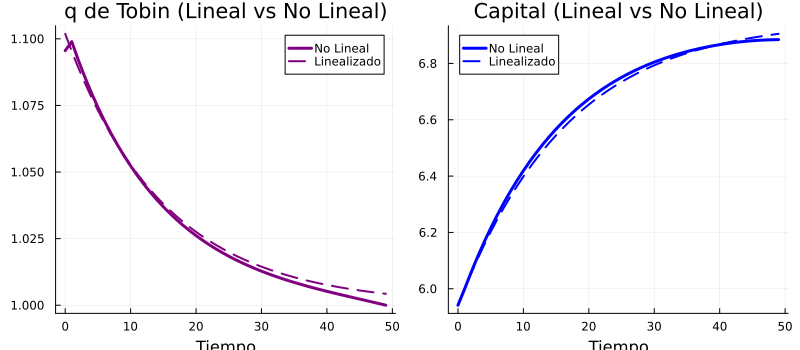

In [4]:
# Comparación Lineal vs No Lineal
params = TobinQParams(0.33, 0.06, 10.0, 0.04)
ss_init = compute_steady_state(params, 0.04)
K0 = ss_init["K"]
T_sim = 50

R_path = fill(0.03, T_sim)
R_path[1] = 0.04

res_lin = solve_linearized_simulation(params, K0, R_path, T_sim)
res_nonlin = solve_nonlinear_simulation(params, K0, R_path, T_sim)

t_axis = 0:(T_sim - 1)

p1 = plot(t_axis, res_nonlin["q"], label="No Lineal", color=:purple, lw=3)
plot!(t_axis, res_lin["q"], label="Linealizado", color=:purple, ls=:dash, lw=2)
title!("q de Tobin (Lineal vs No Lineal)")
xlabel!("Tiempo")

p2 = plot(t_axis, res_nonlin["K"], label="No Lineal", color=:blue, lw=3)
plot!(t_axis, res_lin["K"], label="Linealizado", color=:blue, ls=:dash, lw=2)
title!("Capital (Lineal vs No Lineal)")
xlabel!("Tiempo")

plot(p1, p2, layout=(1,2), size=(800, 350))


## 4. Diagrama de Fases Interactivo

El diagrama de fases permite visualizar geométricamente el comportamiento dinámico del sistema en el espacio de estados $(\hat{k}, \hat{q})$. En este plano:
*   El **locus de capital** ($\Delta \hat{k} = 0$) es la recta horizontal $\hat{q} = 0$.
*   El **locus de valor** ($\Delta \hat{q} = 0$) es una recta con pendiente negativa.
*   El **saddle path** (trayectoria estable) es la recta $\hat{q} = \theta \hat{k}$.

Cuando ocurre el shock de interés (reducción de la tasa de descuento), las variables de desviación se calculan respecto al *nuevo* estado estacionario (que pasa a ser el origen $(0,0)$).
El capital inicial $\hat{k}_1$ está a la izquierda del origen (dado que el nuevo capital de largo plazo es mayor, el capital inicial representa una desviación negativa). 
1. La economía comienza en la recta horizontal del estado estacionario previo (punto rojo).
2. Al ocurrir el shock, la variable forward-looking $q$ salta verticalmente hacia arriba hasta la recta del **saddle path** (punto naranja).
3. A partir del punto de salto, las fuerzas dinámicas del sistema empujan a la economía de forma gradual a lo largo del saddle path hasta alcanzar el nuevo estado estacionario en el origen (estrella verde).


In [5]:
# Diagrama de Fases
@manipulate for R_init in 0.02:0.005:0.06, R_final in 0.02:0.005:0.06, phi_val in 1.0:1.0:20.0, delta_val in 0.02:0.01:0.10, alpha_val in 0.2:0.05:0.4
    params_base = TobinQParams(alpha_val, delta_val, phi_val, R_init)
    ss_init = compute_steady_state(params_base)
    K0 = ss_init["K"]
    T_sim = 40
    
    R_path = fill(R_final, T_sim)
    R_path[1] = R_init
    res = solve_nonlinear_simulation(params_base, K0, R_path, T_sim)
    
    params_final = TobinQParams(alpha_val, delta_val, phi_val, R_final)
    ss_final = compute_steady_state(params_final)
    
    p1 = plot(res["K"], res["q"], color=:purple, lw=3, label="Trayectoria de silla")
    scatter!([ss_init["K"]], [ss_init["q"]], color=:gray, markersize=6, label="EE Inicial")
    scatter!([ss_final["K"]], [ss_final["q"]], color=:black, marker=:star, markersize=8, label="EE Final")
    
    hline!([1.0], color=:blue, ls=:dash, label="dq = 0")
    vline!([ss_final["K"]], color=:red, ls=:dash, label="dK = 0")
    
    title!("Diagrama de Fases (K, q)")
    xlabel!("Capital (K)")
    ylabel!("Q de Tobin (q)")
    
    plot(p1, size=(600, 400), plot_title="Ajuste Dinámico", top_margin=10mm)
end


Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Scope(Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :label), Any["R_init"], Dict{Symbol, Any}(:className => "interact ", :style => Dict{Any, Any}(:padding => "5px 10px 0px 10px")))], Dict{Symbol, Any}(:className => "interact-flex-row-left")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :input), Any[], Dict{Symbol, Any}(:max => 9, :min => 1, :attributes => Dict{Any, Any}(:type => "range", Symbol("data-bind") => "numericValue: index, valueUpdate: 'input', event: {change: function (){this.changes(this.changes()+1)}}", "orient" => "horizontal"), :step => 1, :className => "slider slider is-fullwidth", :style => Dict{Any, Any}()))], Dict{Symbol, Any}(:className => "interact-flex-row-center")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :p), Any[], Dict{Symbol, Any}(:attributes => Dict("data-bind" => "text: formatted_val")))], Dict{Symbol, Any}(:className => "interact-flex-row-right"))], Dict{Symbol, Any}(:className => "interact-flex-row interact-widget")), Dict{String, Tuple{AbstractObservable, Union{Nothing, Bool}}}("changes" => (Observable(0), nothing), "index" => (Observable{Any}(5), nothing)), Set{String}(), nothing, Asset[Asset("js", "knockout", "C:\\Users\\AntonioRC\\.julia\\packages\\Knockout\\HReiN\\src\\..\\assets\\knockout.js"), Asset("js", "knockout_punches", "C:\\Users\\AntonioRC\\.julia\\packages\\Knockout\\HReiN\\src\\..\\assets\\knockout_punches.js"), Asset("js", nothing, "C:\\Users\\AntonioRC\\.julia\\packages\\InteractBase\\8TTmI\\src\\..\\assets\\all.js"), Asset("css", nothing, "C:\\Users\\AntonioRC\\.julia\\packages\\InteractBase\\8TTmI\\src\\..\\assets\\style.css"), Asset("css", nothing, "C:\\Users\\AntonioRC\\.julia\\packages\\Interact\\PENUy\\src\\..\\assets\\bulma_confined.min.css")], Dict{Any, Any}("changes" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"changes\"]()) ? (this.valueFromJulia[\"changes\"]=true, this.model[\"changes\"](val)) : undefined})")], "index" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"index\"]()) ? (this.valueFromJulia[\"index\"]=true, this.model[\"index\"](val)) : undefined})")]), WebIO.ConnectionPool(Channel{Any}(32), Set{AbstractConnection}(), Base.GenericCondition(ReentrantLock())), WebIO.JSString[WebIO.JSString("function () {\n    var handler = (function (ko, koPunches) {\n    ko.punches.enableAll();\n    ko.bindingHandlers.numericValue = {\n        init: function(element, valueAccessor, allBindings, data, context) {\n            var stringified = ko.observable(ko.unwrap(valueAccessor()));\n            stringified.subscribe(function(value) {\n                var val = parseFloat(value);\n                if (!isNaN(val)) {\n                    valueAccessor()(val);\n                }\n            });\n            valueAccessor().subscribe(function(value) {\n                var str = JSON.stringify(value);\n                if ((str == \"0\") && ([\"-0\", \"-0.\"].indexOf(stringified()) >= 0))\n                     return;\n                 if ([\"null\", \"\"].indexOf(str) >= 0)\n                     return;\n                stringified(str);\n            });\n            ko.applyBindingsToNode(\n                element,\n                {\n                    value: stringified,\n                    valueUpdate: allBindings.get('valueUpdate'),\n                },\n                context,\n            );\n        }\n    };\n    var json_data = {\"formatted_vals\":[\"0.02\",\"0.025\",\"0.03\",\"0.035\",\"0.04\",\"0.045\",\"0.05\",\"0.055\",\"0.06\"],\"changes\":WebIO.getval({\"name\":\"changes\",\"scope\":\"5490532760452010759\",\"id\":\"24\",\"type\":\"observable\"}),\"index\":WebIO.getval({\"name\":\"index\",\"scope\":\"5490532760452010759\",\"id\":\"23\",\"type\":\"observable\"})};\n    var self = this;\n    function

## 5. Cuaderno de Bitácora (Actividades para el Alumno)

Responde a las siguientes cuestiones tras interactuar con las simulaciones de la inversión empresarial:

1.  **Interpretación Económica del Salto de $q_t$**:
    *   Al reducirse la tasa de interés de 4% a 3%, explica por qué el ratio Q de Tobin marginal ($q_1$) salta instantáneamente por encima de 1.0. ¿Qué representa esto desde la perspectiva del valor de la empresa frente a sus costes de instalación?
    *   ¿Por qué el stock de capital ($K_t$) no puede dar un salto similar en $t=1$? ¿Qué pasaría si la empresa intentara realizar una inversión infinita para cubrir la brecha al instante?
2.  **Análisis de Sensibilidad de los Costes de Ajuste ($\phi$)**:
    *   En la simulación 2, aumenta el parámetro de costos de ajuste $\phi$ de 10 a 25. Observa el comportamiento del capital ($K_t$) y la inversión ($I_t$). ¿Qué ocurre con la velocidad de convergencia al nuevo estado estacionario?
    *   ¿Cómo cambia la magnitud del salto inicial de $q_1$ al aumentar $\phi$? Explica la intuición económica tras este resultado.
3.  **Diagrama de Fases y Estabilidad**:
    *   Utilizando el diagrama de fases interactivo, describe detalladamente la transición del sistema desde el pre-shock (punto rojo) hasta el post-shock inmediato (punto naranja) y la subsecuente trayectoria continua hasta el origen (estrella verde).
    *   ¿Qué ocurriría si $q_t$ diera un salto incorrecto (por ejemplo, a un valor de $q_1 = 1.05$ en lugar de su valor teórico estable de $1.1033$)? Observa las líneas de flujo del campo vectorial fuera del saddle path para razonar tu respuesta.


## 6. Buenas Prácticas Aplicadas en este Laboratorio
1.  **Aislamiento de Lógica Computacional**: La resolución numérica no lineal y el análisis matricial están desacoplados de las celdas didácticas de visualización, residiendo enteramente en el módulo [tobin_q.py](file:///c:/Users/AntonioRC/Desktop/PIE/src/macroaicomp/models/tobin_q.py).
2.  **Identidad Algebraica en Códigos**: Hemos verificado en los unit tests que la fórmula simplificada de salto estable ($\theta = \phi \lambda_1$) y la ecuación extendida del libro son exactamente idénticas, simplificando el código didáctico notablemente.
3.  **Higiene del Repositorio**: Antes de cada confirmación de commit, los outputs de este cuaderno se eliminan automáticamente mediante `nbstripout` para evitar el almacenamiento ineficiente de imágenes y datos pesados.


## 7. Benchmark de Rendimiento (Fase III)
Evaluamos la velocidad de simulación usando `BenchmarkTools.jl`.

In [6]:
# Benchmark simulation
@btime solve_nonlinear_simulation($params, $K0, $R_path, $T_sim)


  18.098 ms (1380022 allocations: 24.05 MiB)

Dict{String, Vector{Float64}} with 4 entries:
  "Y" => [1.80048, 1.80614, 1.81201, 1.8175, 1.82263, 1.82741, 1.83188, 1.83606…
  "I" => [0.413281, 0.41925, 0.419226, 0.419189, 0.419141, 0.419083, 0.419018, …
  "K" => [5.94157, 5.99836, 6.05771, 6.11347, 6.16585, 6.21504, 6.26122, 6.3045…
  "q" => [1.09557, 1.09894, 1.09205, 1.08568, 1.07978, 1.0743, 1.06923, 1.06451…